# QNP-based SQD implementation for CO$_2$@MOF

This notebook presents a simple Qiskit implementation of the QNP ansatz <br>
https://iopscience.iop.org/article/10.1088/1367-2630/ac2cb3/meta <br>
The specific case considered here is the (14,14) active space of CO$_2$ adsorbed in MOF-74. The simulation involves 28 qubits and 4 layers depth. This is not sufficient to achieve chemical accuracy within the standard VQE approach but, as shown below, noisy sample-based quantum diagonalization (SQD) can further improve accuracy.<br> 
To simplify future simulations on harware, the QNP ansatz uses fixed parameters obtained from Quicksilver (the optimization itself could be challenging in the presence of noise). 

Set up quantum circuit

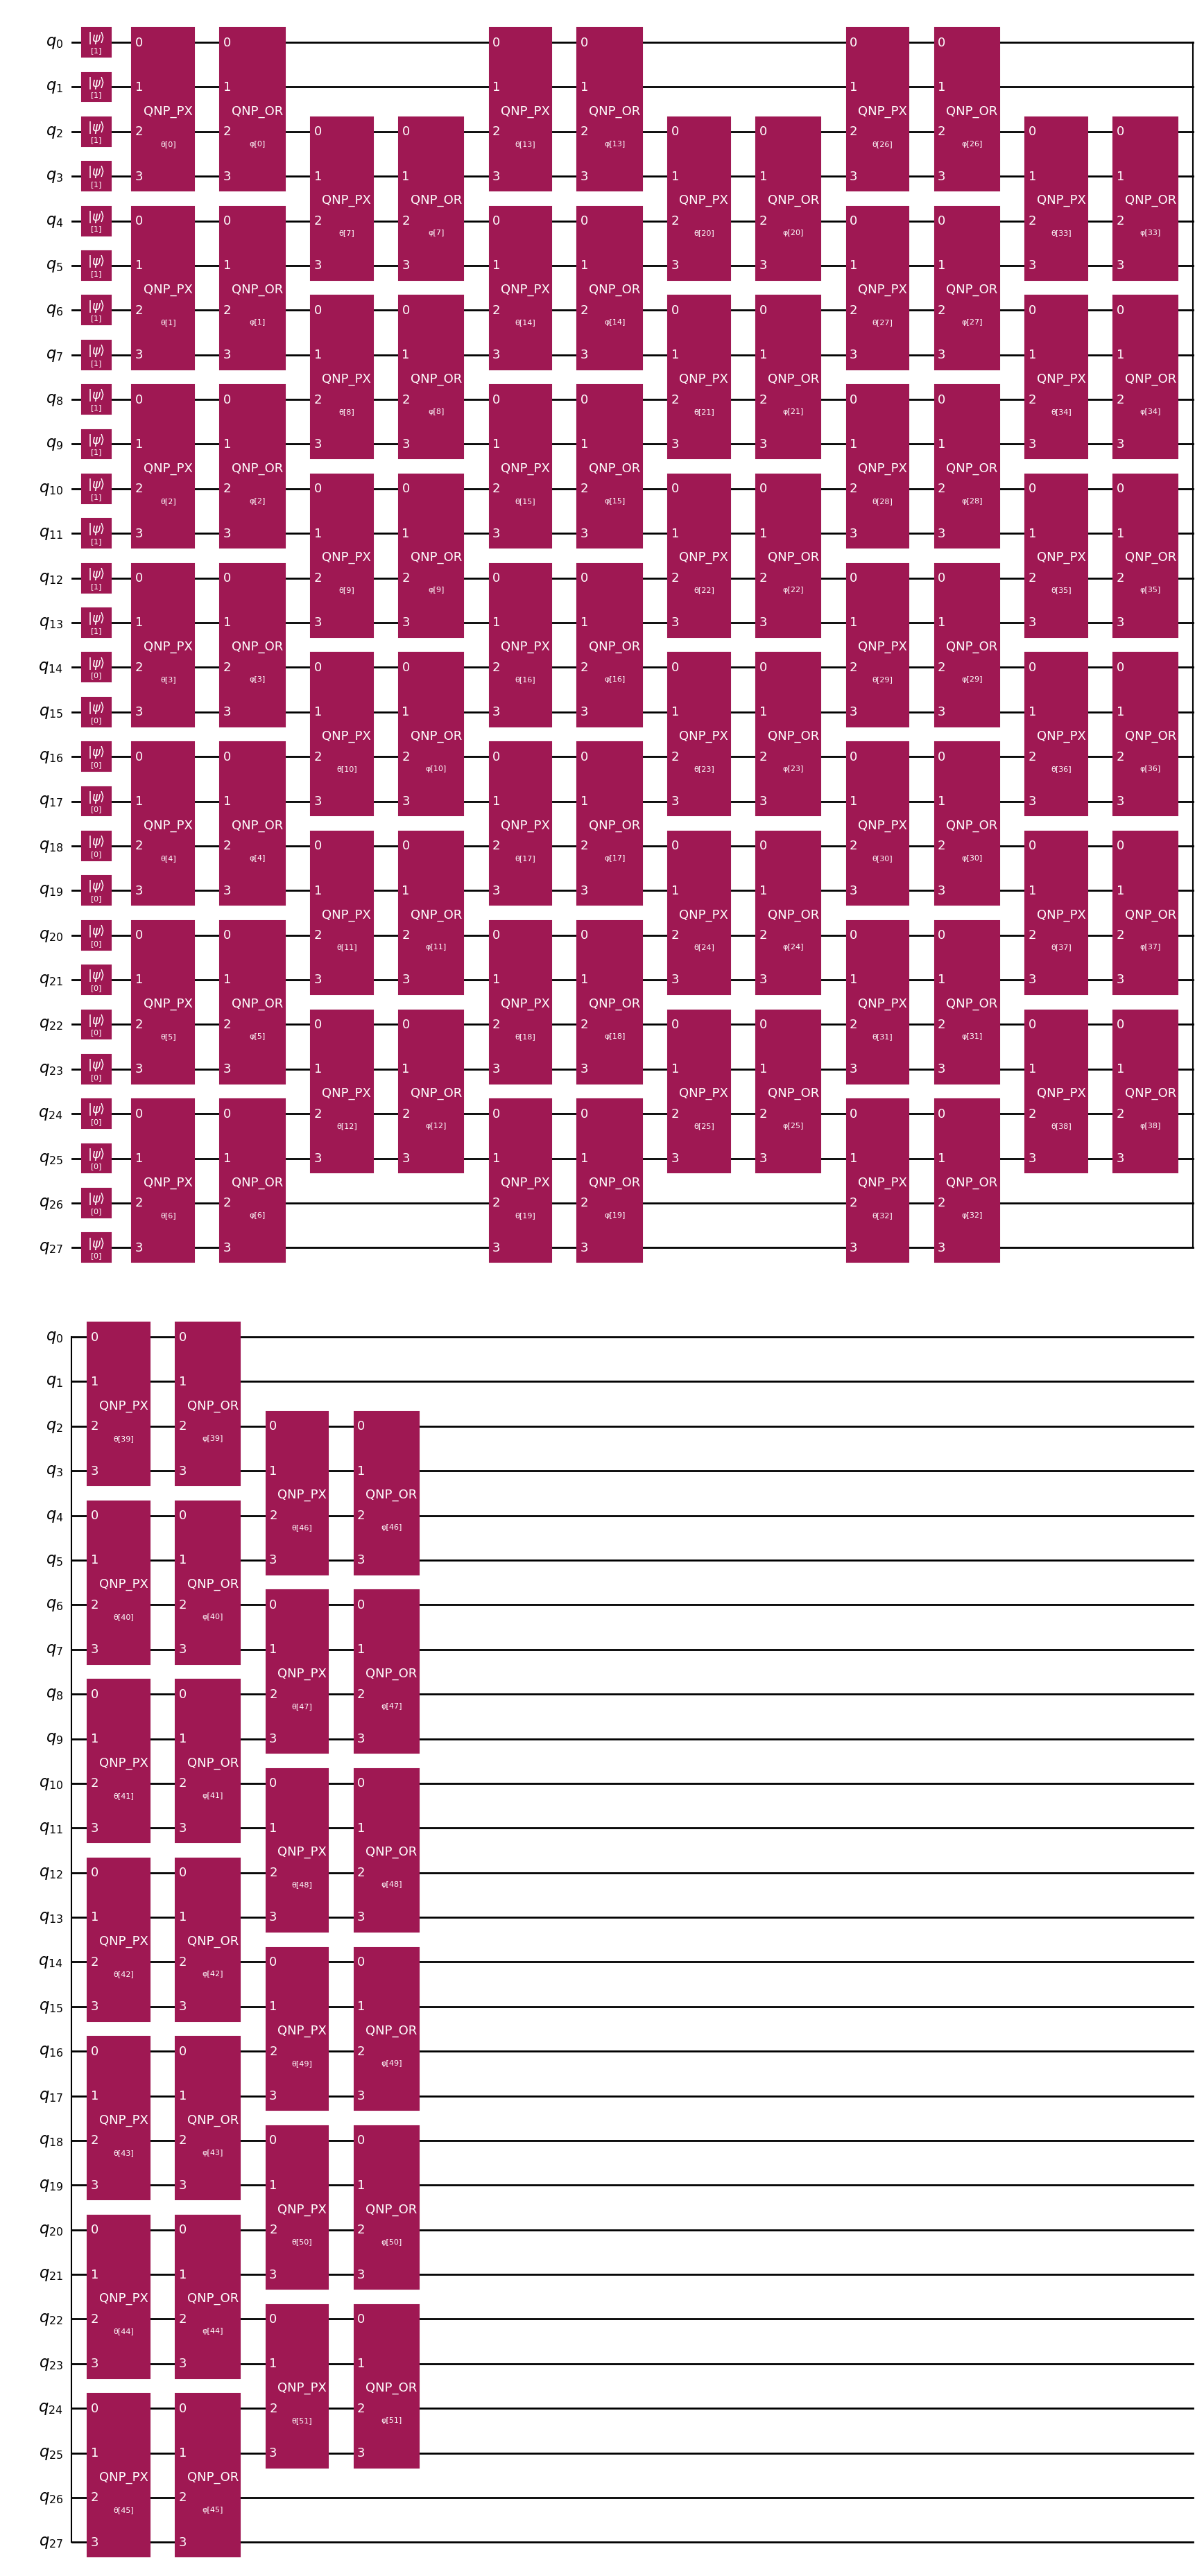

In [1]:
import numpy as np
import sys
sys.path.append('../../../qnp_vqe_qiskit_simulator/qnp_utils/')
from qnp_utils import count_QNP_params, initialize_HF, QNP_fabric
from qiskit.circuit import ParameterVector
from qiskit import QuantumCircuit

n_layers = 4
n_qbits = 28
intfile = '../../../fullci_reference_pyscf/singlet/MOFCO2integrals.npz'
integrals = np.load(intfile)
nelec = int(integrals['Nelec'])

n_theta, n_phi = count_QNP_params(n_qbits, n_layers)

theta = ParameterVector('θ', n_theta)
phi = ParameterVector('φ', n_phi)

qnp_circ = QuantumCircuit(n_qbits)
initialize_HF(qnp_circ,nelec)
QNP_fabric(qnp_circ, n_layers, theta, phi)

# Draw the main circuit
qnp_circ.draw('mpl')

Set up Hamiltonian 

In [2]:
from qiskit_nature.second_q.hamiltonians import ElectronicEnergy
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit.quantum_info import SparsePauliOp
from qnp_utils import reorder_alphabeta_to_interleaved

#Load the active space integrals defining the Hamiltonian 
H0 = integrals['Ecore']
H1 = integrals['Hact']
H2 = integrals['Iact']

print(f"H0: {H0}")
print(f"H1 type: {type(H1)}, H1 shape {H1.shape}")
print(f"H2 type: {type(H2)}, H2 shape {H2.shape}")

#Setting up the electronic Hamiltonian from H1 and H2 integrals
hamiltonian = ElectronicEnergy.from_raw_integrals(H1, H2)
hamiltonian.nuclear_repulsion_energy = H0 # This is just a constant in the Hamiltonian

#Hamiltonian in second quantization
second_q_H = hamiltonian.second_q_op()

#Fermion to qubit mapping
mapper = JordanWignerMapper()
qubit_jw_H = mapper.map(second_q_H)

#Changing Pauli strings to interleaved order 
pauli_terms = qubit_jw_H.paulis  
coeffs = qubit_jw_H.coeffs
interleaved_pauli = reorder_alphabeta_to_interleaved(pauli_terms)
qubit_jw_H = SparsePauliOp.from_list(list(zip(interleaved_pauli, coeffs)))

H0: 0.0
H1 type: <class 'numpy.ndarray'>, H1 shape (14, 14)
H2 type: <class 'numpy.ndarray'>, H2 shape (14, 14, 14, 14)


Use Qiskit to compute the exact expectation value

Qiskit estimate of ground state energy (exact estimator): -74.47537759352146 Ha
Deviation from reference FCI: 0.2306089327372547 Ha
Deviation of Quicksilver:     0.23061689112084593 Ha


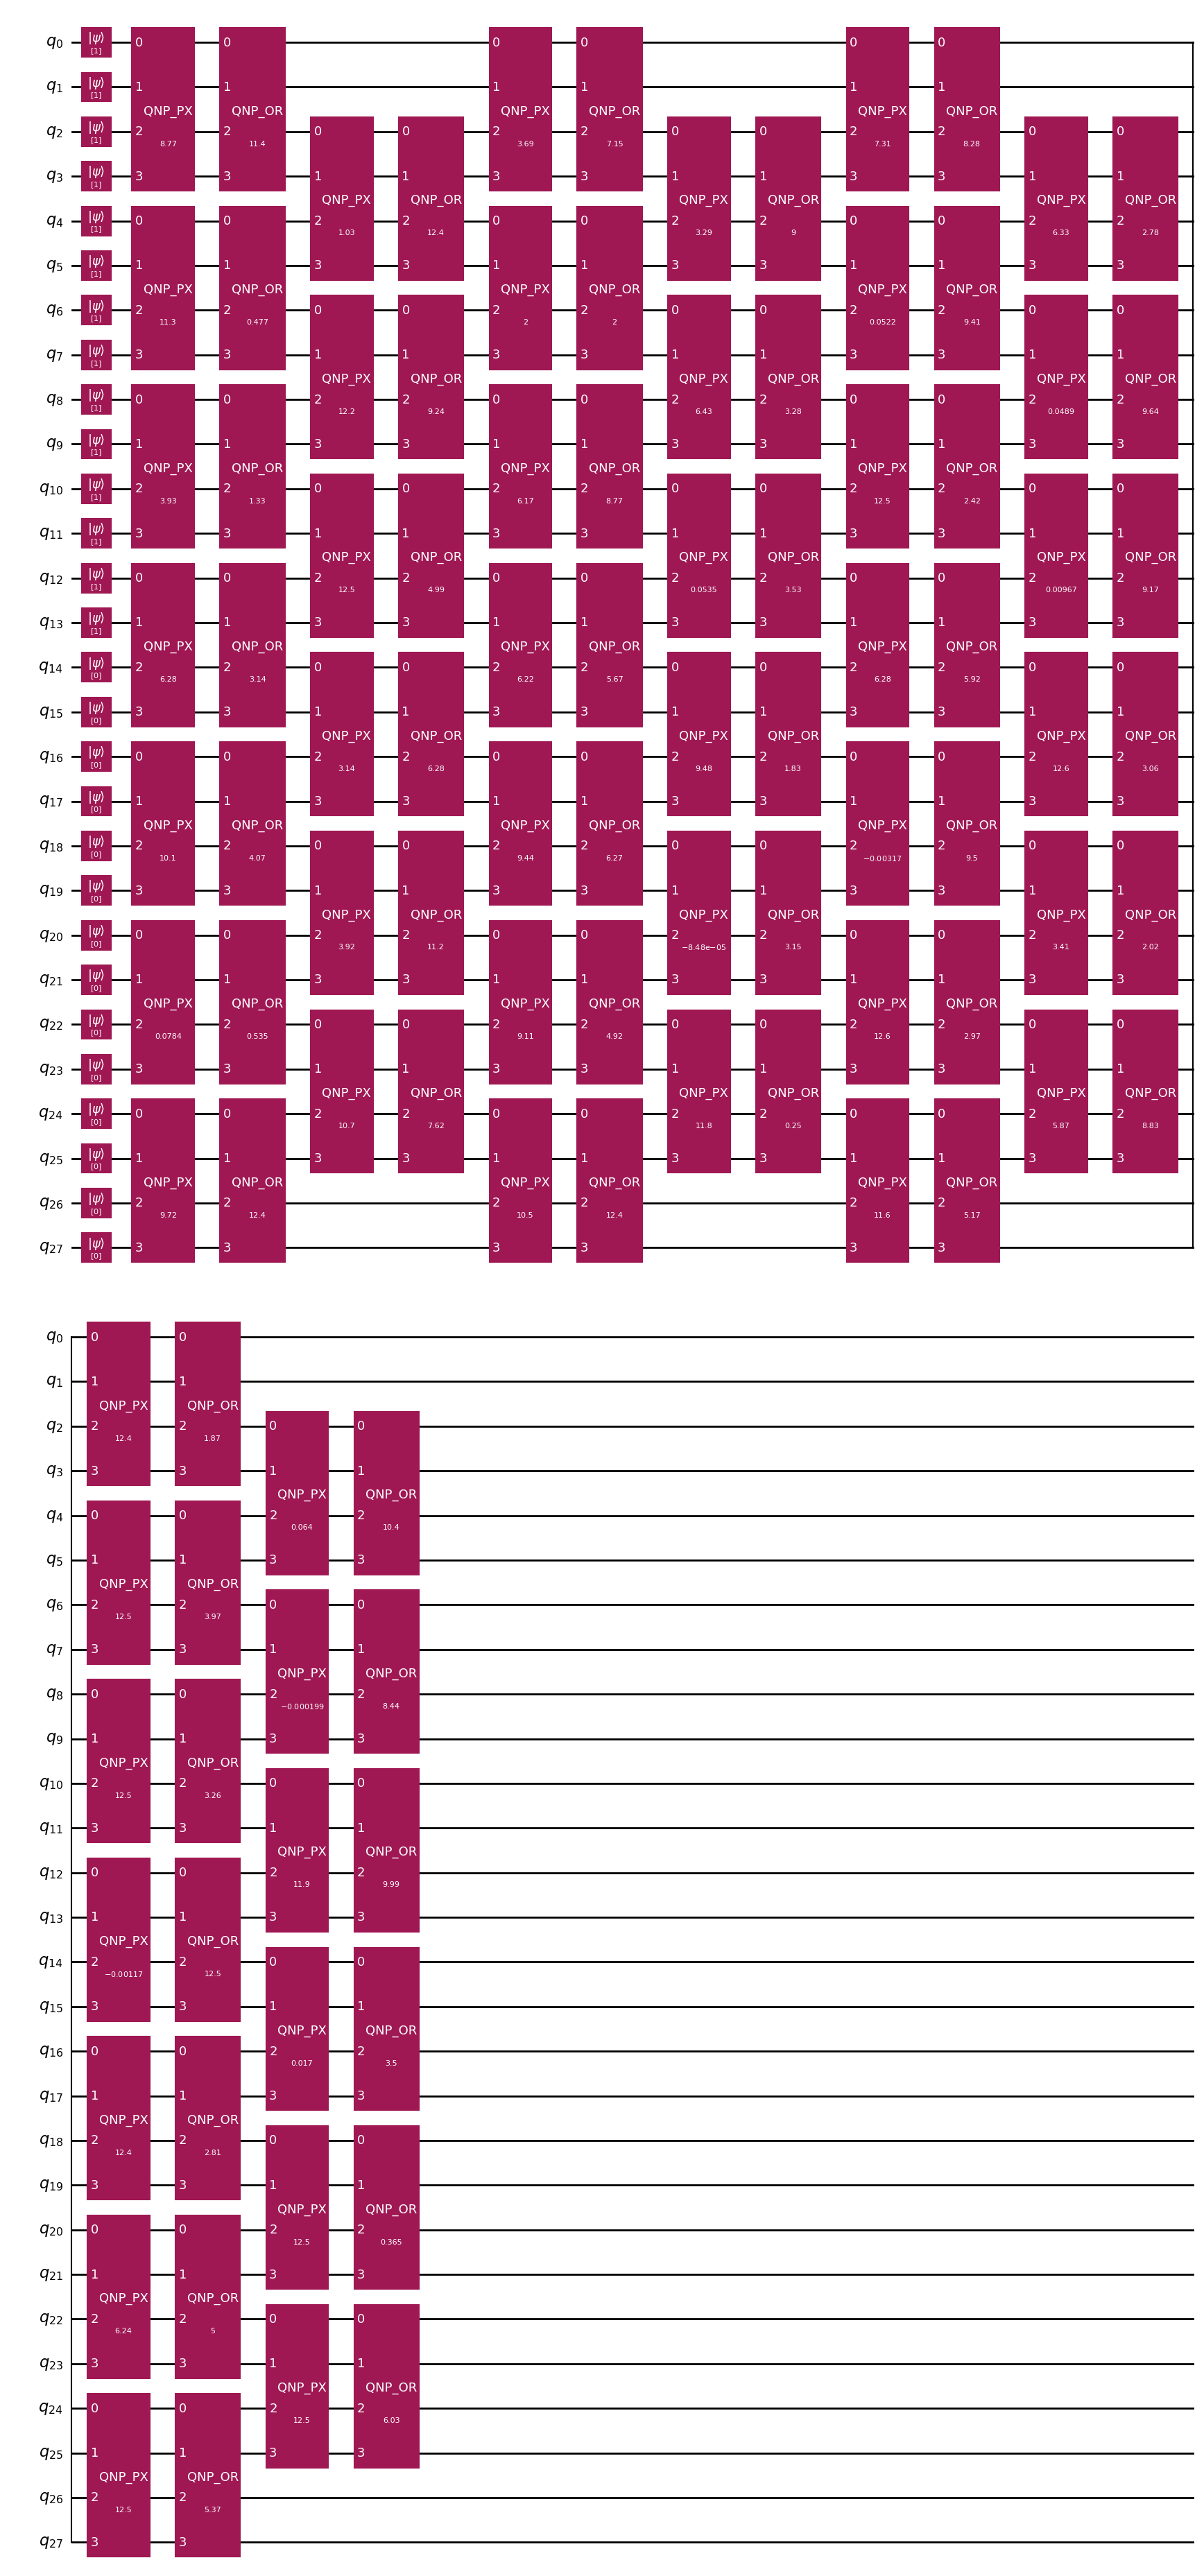

In [3]:
from qiskit.primitives import StatevectorEstimator
from qiskit.circuit import Parameter, ParameterVector
from qnp_utils import assign_parameters_from_file

#Reference FCI value
E_FCI = integrals['Efci']

exact_estimator = StatevectorEstimator()

parfile='optimized_params.txt'
qnp_fix_param = assign_parameters_from_file(parfile, qnp_circ, n_layers, theta, phi)

results = exact_estimator.run([(qnp_fix_param, qubit_jw_H)]).result()
qiskit_exact_GSenergy=results[0].data.evs+H0

print(f"Qiskit estimate of ground state energy (exact estimator): {qiskit_exact_GSenergy} Ha")
print(f"Deviation from reference FCI: {qiskit_exact_GSenergy-E_FCI} Ha")
print("Deviation of Quicksilver:     0.23061689112084593 Ha")
qnp_fix_param.draw('mpl')

### Subspace of determinants from Quicksilver

We have used Quicksilver to determine the subspace of the ``dominant'' determinants. Specifically, we selected all the determinants whose squared coefficient (namely the probability to be sampled) is larger than 10$^{-6}$. This procedure is not stochastic but includes the set of determinants that are most likely to be sampled within the SQD approach using a small multiple of 100k shots. Since using Qiskit to sample bitstrings exactly for CO$_2$ adsorbed in MOF-74 is too expensive, here we will consider only this estimate instead of fully simulating SQD.

In [4]:
counts_qs = np.load("exact_counts_fullcircuit_qs.npy", allow_pickle=True).item()

In [5]:
pyscf_counts={'1011000000000011011111110011' : 0.04693034440548595, '0111000000000011101111110011' : 0.04691765912723958, '0111000000000011111011110011' : 0.03405373181245861, '1011000000000011110111110011' : 0.034014544124247155, '0011100000000011011111110011' : 0.016762788419935504, '0011010000000011101111110011' : 0.016756572638961995, '1011000000000011011111110110' : 0.01331499465428097, '0111000000000011101111111001' : 0.013298774564582484, '0011010000000011111011110011' : 0.011815254665660071, '0011100000000011110111110011' : 0.011802047647716585, '1110000000000011011111110011' : 0.010021715622961886}

counts_qs_interleaved = {}
for s, val in counts_qs.items():
    det_a = s[n_qbits//2:]
    det_b = s[:n_qbits//2]
    det_string = ''.join(det_b[i] + det_a[i] for i in range(n_qbits//2))
    counts_qs_interleaved[det_string] = val

for det, prob in pyscf_counts.items():

    if det in counts_qs_interleaved:
        print(f"{det} is included in the exact QNP state (within a 10^-6 threshold)")
    else:
        print(f"{det} is not included in the exact QNP state (within a 10^-6 threshold)")

1011000000000011011111110011 is not included in the exact QNP state (within a 10^-6 threshold)
0111000000000011101111110011 is not included in the exact QNP state (within a 10^-6 threshold)
0111000000000011111011110011 is not included in the exact QNP state (within a 10^-6 threshold)
1011000000000011110111110011 is not included in the exact QNP state (within a 10^-6 threshold)
0011100000000011011111110011 is included in the exact QNP state (within a 10^-6 threshold)
0011010000000011101111110011 is included in the exact QNP state (within a 10^-6 threshold)
1011000000000011011111110110 is not included in the exact QNP state (within a 10^-6 threshold)
0111000000000011101111111001 is not included in the exact QNP state (within a 10^-6 threshold)
0011010000000011111011110011 is included in the exact QNP state (within a 10^-6 threshold)
0011100000000011110111110011 is included in the exact QNP state (within a 10^-6 threshold)
1110000000000011011111110011 is not included in the exact QNP stat

In [6]:
from qiskit_addon_sqd.fermion import solve_fermion
from qiskit_addon_sqd.counts import counts_to_arrays

bitstring_matrix_qs, _ = counts_to_arrays(counts_qs)
energy_qs, _, _, _ = solve_fermion(bitstring_matrix_qs, H1, H2)
print(f"Deviation of Quicksilver subspace energy from reference FCI: {energy_qs-E_FCI} Ha")

Deviation of Quicksilver subspace energy from reference FCI: 0.13806173724870519 Ha
